# 01 · Data Exploration

**Goal:** understand the raw Olist files before any analysis. What they contain, where they are
incomplete, which problems the pipeline had to solve, and which period is reliable enough to analyse.

**Sources:** the raw CSV files in `data/raw/` and the PostgreSQL database loaded by `python -m data_pipeline`.
Every number in this notebook is computed in the cells below.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))   # project root, for data_pipeline

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import Markdown, display

from nexus_nb import AXIS, GRID, INK, MUTED_FILL, SEQUENTIAL_BLUE, SERIES, brl, query

from data_pipeline.ingestion import read_raw

raw = read_raw(download=False)

## 1. Raw files at a glance

In [2]:
overview = pd.DataFrame({
    "rows": {k: len(v) for k, v in raw.items()},
    "columns": {k: v.shape[1] for k, v in raw.items()},
    "missing_cells": {k: int(v.isna().sum().sum()) for k, v in raw.items()},
    "exact_duplicate_rows": {k: int(v.duplicated().sum()) for k, v in raw.items()},
}).sort_values("rows", ascending=False)
overview.loc["TOTAL"] = overview.sum()
overview

,rows,columns,missing_cells,exact_duplicate_rows
geolocation,1000163,5,0,261831
order_items,112650,7,0,0
payments,103886,5,0,0
customers,99441,5,0,0
orders,99441,8,4908,0
reviews,99224,7,145903,0
products,32951,9,2448,0
sellers,3095,4,0,0
category_translation,71,2,0,0
TOTAL,1550922,52,153259,261831


## 2. Where are values missing?

Missing values are not all errors. Review titles and messages are optional, so a customer may
leave a score without writing anything. Missing delivery dates are expected for orders that have not
been delivered. The pipeline treats each case differently (see section 4).

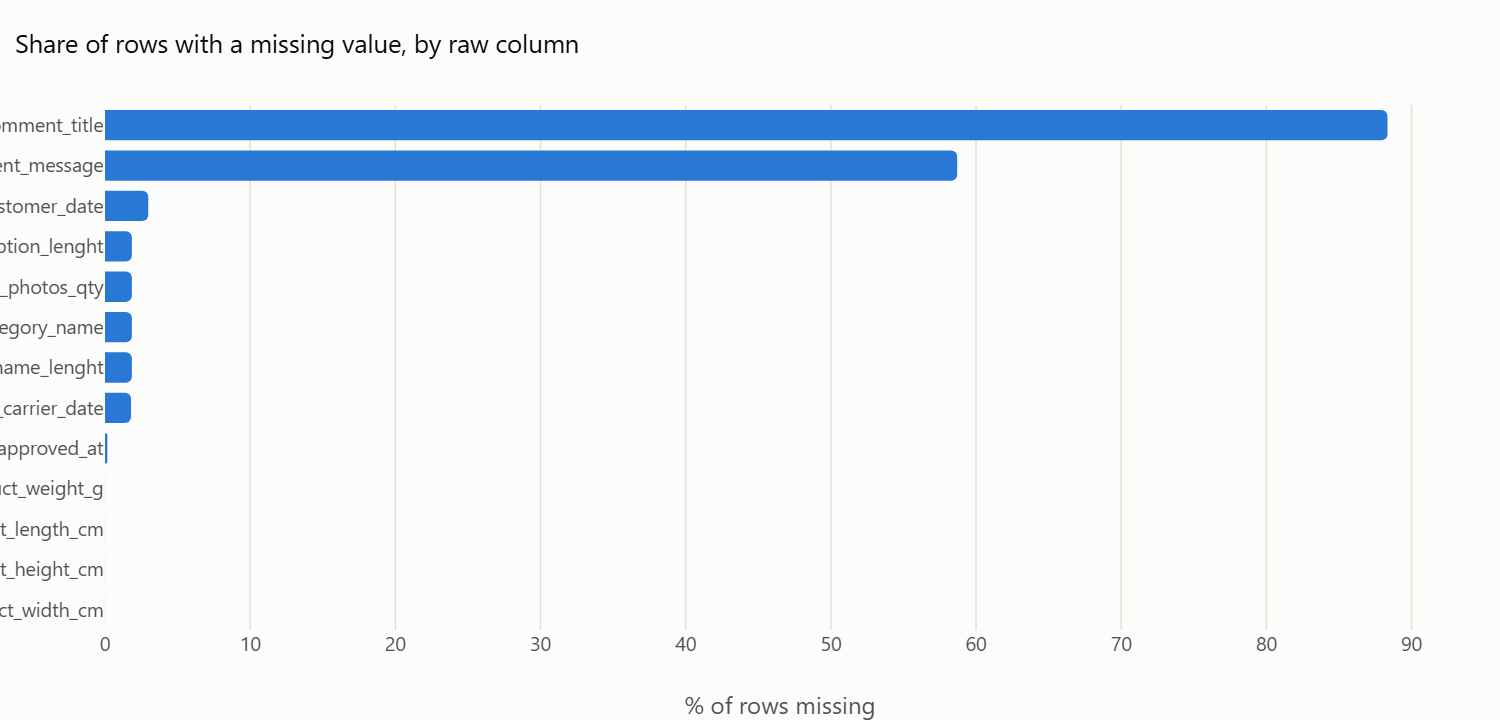

,% missing
products.product_width_cm,0.01
products.product_height_cm,0.01
products.product_length_cm,0.01
products.product_weight_g,0.01
orders.order_approved_at,0.16
orders.order_delivered_carrier_date,1.79
products.product_name_lenght,1.85
products.product_category_name,1.85
products.product_photos_qty,1.85
products.product_description_lenght,1.85


In [3]:
missing = pd.concat({name: df.isna().mean() for name, df in raw.items()}).rename("missing_share")
missing = missing[missing > 0].sort_values()
labels = [f"{table}.{column}" for table, column in missing.index]

fig = go.Figure(go.Bar(x=missing.values * 100, y=labels, orientation="h", marker_color=SERIES[0],
                       hovertemplate="%{y}: %{x:.2f}%<extra></extra>"))
fig.update_layout(title="Share of rows with a missing value, by raw column", height=520,
                  xaxis=dict(title="% of rows missing", showgrid=True, gridcolor=GRID), yaxis=dict(showgrid=False))
fig.show()
(missing * 100).round(2).set_axis(labels).rename("% missing").to_frame()

## 3. Who is the customer?

Olist issues a new `customer_id` for **every order**. The person behind the orders is `customer_unique_id`.
Treating `customer_id` as the customer would make every buyer look new and would make retention, CLV,
RFM and churn analysis meaningless. That is why `core.customers` is keyed on `customer_unique_id`.

In [4]:
c = raw["customers"]
orders_per_person = c.groupby("customer_unique_id").size()
display(pd.Series({
    "distinct customer_id (one per order)": c["customer_id"].nunique(),
    "distinct customer_unique_id (people)": c["customer_unique_id"].nunique(),
}).to_frame("count"))
orders_per_person.value_counts().sort_index().rename_axis("orders per person").to_frame("people")

,count
distinct customer_id (one per order),99441
distinct customer_unique_id (people),96096


,people
orders per person,
1,93099
2,2745
3,203
4,30
5,8
6,6
7,3
9,1
17,1


## 4. Data-quality report

The pipeline records every check it runs in `ops.data_quality_issues`. The view
`analytics.v_data_quality_latest` exposes the latest successful run, which is what the dashboard shows.

In [5]:
run = query("""
    SELECT run_id, finished_at, rows_read, rows_loaded
    FROM ops.pipeline_runs
    WHERE run_id = (SELECT max(run_id) FROM ops.pipeline_runs WHERE status = 'success')
""")
dq = query("""
    SELECT source_table, check_name, category, severity, rows_affected, action_taken
    FROM analytics.v_data_quality_latest
""")
by_category = (dq.groupby("category")
                 .agg(checks=("check_name", "count"),
                      checks_with_findings=("rows_affected", lambda s: int((s > 0).sum())),
                      rows_affected=("rows_affected", "sum"))
                 .sort_values("rows_affected", ascending=False))
display(run)
by_category

,run_id,finished_at,rows_read,rows_loaded
0,2,2026-09-27 22:31:36.762571+00:00,1550922,563733


,checks,checks_with_findings,rows_affected
category,,,
duplicate,9,1,261831
format,38,7,88544
outlier,3,3,5835
invalid_date,8,4,1446
inconsistency,7,7,1357
missing,10,6,943
invalid_value,24,4,22
referential,6,0,0


In [6]:
# Every check that found something, largest first.
dq[dq["rows_affected"] > 0].sort_values("rows_affected", ascending=False).reset_index(drop=True)

,source_table,check_name,category,severity,rows_affected,action_taken
0,geolocation,duplicate_rows,duplicate,warning,261831,removed
1,geolocation,city_name_format,format,warning,63459,corrected
2,customers,zip_leading_zeros_lost,format,warning,23995,corrected
3,order_items,freight_outlier_within_category,outlier,warning,4227,flagged
4,order_items,price_outlier_within_category,outlier,warning,1575,flagged
5,orders,carrier_pickup_before_approval,invalid_date,warning,1193,flagged
6,sellers,zip_leading_zeros_lost,format,warning,1027,corrected
7,orders,order_without_items,inconsistency,warning,775,kept
8,products,category_missing,missing,warning,610,imputed
9,payments,paid_differs_from_items_plus_freight,inconsistency,warning,312,flagged


## 5. From raw rows to the relational model

In [7]:
loaded = query("""
    SELECT 'customers' AS source, 'core.customers' AS target, count(*) AS rows_loaded FROM core.customers
    UNION ALL SELECT 'sellers',      'core.sellers',        count(*) FROM core.sellers
    UNION ALL SELECT 'products',     'core.products',       count(*) FROM core.products
    UNION ALL SELECT 'orders',       'core.orders',         count(*) FROM core.orders
    UNION ALL SELECT 'order_items',  'core.order_items',    count(*) FROM core.order_items
    UNION ALL SELECT 'payments',     'core.order_payments', count(*) FROM core.order_payments
    UNION ALL SELECT 'reviews',      'core.order_reviews',  count(*) FROM core.order_reviews
    UNION ALL SELECT 'geolocation',  'core.locations',      count(*) FROM core.locations
""")
loaded["rows_raw"] = loaded["source"].map({k: len(v) for k, v in raw.items()})
loaded["difference"] = loaded["rows_loaded"] - loaded["rows_raw"]
loaded[["source", "rows_raw", "target", "rows_loaded", "difference"]]

,source,rows_raw,target,rows_loaded,difference
0,sellers,3095,core.sellers,3095,0
1,geolocation,1000163,core.locations,15220,-984943
2,products,32951,core.products,32951,0
3,orders,99441,core.orders,99441,0
4,payments,103886,core.order_payments,103886,0
5,customers,99441,core.customers,96096,-3345
6,order_items,112650,core.order_items,112650,0
7,reviews,99224,core.order_reviews,99224,0


Two tables change size on purpose:

- **customers** shrinks because one row per order becomes one row per person.
- **geolocation** collapses from raw GPS points into one location per zip prefix and city, with a
  robust (median) coordinate.

Every other table is loaded in full.

## 6. Which months can be analysed?

The collection starts and ends with nearly empty months. Treating them as real would create fake
growth at the start and a fake collapse at the end. A month is marked **complete** when it holds at
least 10% of the median monthly volume (`analytics.v_month_coverage`). The last complete month sets
the reference date, which the platform uses as "today".

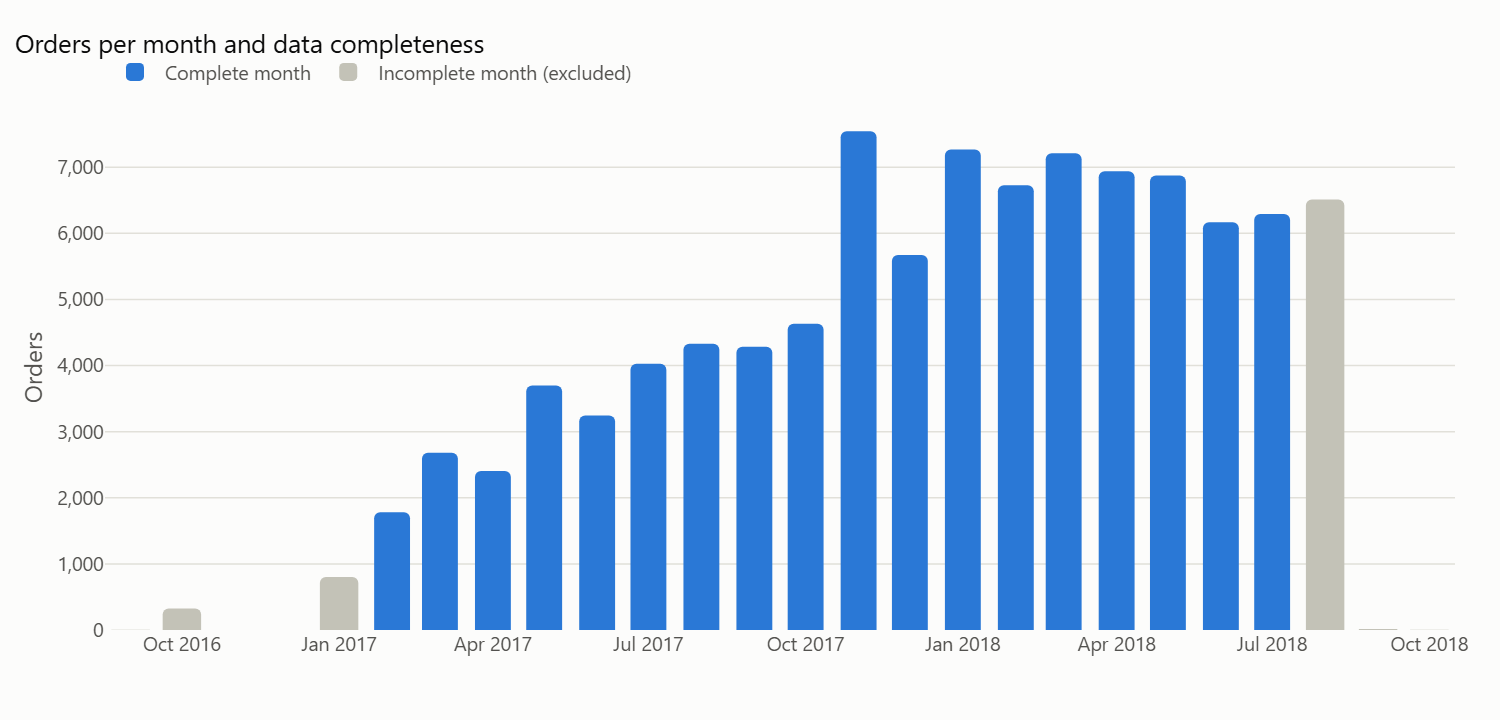

,value
data_start,2017-01-14
data_end,2018-08-23
first_month,2017-02-01
last_month,2018-07-01
reference_date,2018-08-24


In [8]:
coverage = query("SELECT month, orders, is_complete FROM analytics.v_month_coverage ORDER BY month")
period = query("SELECT * FROM analytics.v_reporting_period").iloc[0]

fig = go.Figure()
for complete, name, color in [(True, "Complete month", SERIES[0]), (False, "Incomplete month (excluded)", MUTED_FILL)]:
    part = coverage[coverage["is_complete"] == complete]
    fig.add_bar(x=part["month"], y=part["orders"], name=name, marker_color=color,
                hovertemplate="%{x|%b %Y}: %{y:,} orders<extra></extra>")
fig.update_layout(title="Orders per month and data completeness", yaxis=dict(title="Orders", tickformat=","), barmode="overlay")
fig.show()
display(period.to_frame("value"))

## 7. Findings

Generated from the results above:

In [9]:
dup_geo = int(overview.loc["geolocation", "exact_duplicate_rows"])
people = c["customer_unique_id"].nunique()
repeat_people = int((orders_per_person > 1).sum())
excluded = coverage.loc[~coverage["is_complete"], "orders"].sum()
display(Markdown(f"""
- The raw data has **{int(overview.loc['TOTAL', 'rows']):,} rows** in {len(raw)} files. The largest,
  geolocation, has **{dup_geo:,} exact duplicate rows** ({dup_geo / len(raw['geolocation']):.1%} of the file).
- **{people:,} people** placed the orders, and only **{repeat_people:,} ({repeat_people / people:.1%})** bought more
  than once. Low repeat purchasing is a structural property of this business, and it shapes the churn
  and RFM design.
- The pipeline ran **{len(dq)} checks**, and **{int((dq['rows_affected'] > 0).sum())}** of them found something. Every
  decision (removed, corrected, imputed, nulled or flagged) is stored in the database.
- The reliable analysis window is **{period['first_month']:%b %Y} to {period['last_month']:%b %Y}**. The
  {int((~coverage['is_complete']).sum())} incomplete months hold only {int(excluded):,} orders and are excluded from
  time-based comparisons.
"""))


- The raw data has **1,550,922 rows** in 9 files. The largest,
  geolocation, has **261,831 exact duplicate rows** (26.2% of the file).
- **96,096 people** placed the orders, and only **2,997 (3.1%)** bought more
  than once. Low repeat purchasing is a structural property of this business, and it shapes the churn
  and RFM design.
- The pipeline ran **105 checks**, and **32** of them found something. Every
  decision (removed, corrected, imputed, nulled or flagged) is stored in the database.
- The reliable analysis window is **Feb 2017 to Jul 2018**. The
  8 incomplete months hold only 7,661 orders and are excluded from
  time-based comparisons.
